# 2D tracking trajectory vs real trajectory

这个 notebook 只做一件事：  
**用 2D 图对比要 track 的参考轨迹和真实飞行轨迹。**

默认输入：

- log: `install_test1_79.csv`
- reference trajectory: `next_drone_full_trajectory_landing_frame_20260522_132342.csv`

图里主要看：

- reference trajectory：Python 生成的 `x_local/y_local`
- real trajectory：Crazyflie log 里的 `stateX/stateY`
- command trajectory：firmware 实际给 commander 的 `cmdA/cmdB`
- active tracking segment：`mission_state == 2` 的真实轨迹


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================
# 修改这里
# ============================

log_csv = "data/installation_drone_logs/install_test1_15.csv"
ref_csv = "next_drone_full_trajectory_landing_frame_20260622_191856.csv"

outdir = "track_vs_real_2d_outputs"
os.makedirs(outdir, exist_ok=True)


## 1. Load log and reference trajectory


In [2]:
def clean_numeric_df(path):
    df = pd.read_csv(path)
    df.columns = [str(c).strip() for c in df.columns]
    for c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    return df

def add_time(df):
    df = df.copy()
    if "timeTick" in df.columns:
        df["t"] = (df["timeTick"] - df["timeTick"].iloc[0]) / 1000.0
    elif "time" in df.columns:
        df["t"] = df["time"] - df["time"].iloc[0]
    else:
        df["t"] = np.arange(len(df)) * 0.02
    return df

def pick_col(df, names):
    for n in names:
        if n in df.columns:
            return n
    return None

log = add_time(clean_numeric_df(log_csv))
ref = clean_numeric_df(ref_csv)

ref_x_col = pick_col(ref, ["x_local", "x", "ref_x", "trajx"])
ref_y_col = pick_col(ref, ["y_local", "y", "ref_y", "trajy"])
ref_yaw_col = pick_col(ref, ["yaw_local", "yaw", "ref_yaw"])

if ref_x_col is None or ref_y_col is None:
    raise RuntimeError(f"Cannot find reference x/y columns. ref columns = {list(ref.columns)}")

ref = ref[[ref_x_col, ref_y_col] + ([ref_yaw_col] if ref_yaw_col is not None else [])].copy()
ref = ref.rename(columns={ref_x_col: "x_ref", ref_y_col: "y_ref"})
if ref_yaw_col is not None:
    ref = ref.rename(columns={ref_yaw_col: "yaw_ref"})

ref = ref[np.isfinite(ref["x_ref"]) & np.isfinite(ref["y_ref"])].reset_index(drop=True)

print("log file:", log_csv)
print("ref file:", ref_csv)
print("log shape:", log.shape)
print("ref shape:", ref.shape)

print("\nlog columns:")
print(list(log.columns))

print("\nreference trajectory head:")
display(ref.head())

print("\nlog head:")
display(log.head())


log file: data/installation_drone_logs/install_test1_15.csv
ref file: next_drone_full_trajectory_landing_frame_20260622_191856.csv
log shape: (4276, 19)
ref shape: (44, 3)

log columns:
['timeTick', 'stateX', 'stateY', 'stateZ', 'stateVX', 'stateVY', 'yaw', 'noDynVx', 'noDynVy', 'noDynSpeed', 'mission_state', 'traj_index', 'cmdA', 'cmdB', 'cmdHeight', 'contact', 'trajx', 'trajy', 't']

reference trajectory head:


,x_ref,y_ref,yaw_ref
0,0.000000,0.000000,0.016162
1,0.150050,0.002425,-0.092876
2,0.301332,-0.011666,-0.085821
3,0.452916,-0.024707,-0.048543
4,0.604019,-0.032048,0.002541



log head:


,timeTick,stateX,stateY,stateZ,stateVX,stateVY,yaw,noDynVx,noDynVy,noDynSpeed,mission_state,traj_index,cmdA,cmdB,cmdHeight,contact,trajx,trajy,t
0,10727,-0.001740,-0.000300,0.033590,0.001583,0.000133,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.00
1,10747,-0.001980,0.000477,0.033664,0.000431,0.004048,-0.019252,-0.020335,0.063890,0.067048,0.0,0.0,-0.002446,0.000377,0.3,0.0,0.0,0.0,0.02
2,10767,-0.003007,0.000459,0.033735,-0.004532,0.003564,-0.019500,-0.020335,0.063890,0.067048,0.0,0.0,-0.002446,0.000377,0.3,0.0,0.0,0.0,0.04
3,10787,-0.002002,0.000446,0.033503,0.000472,0.003804,-0.018419,-0.082258,-0.019994,0.084653,0.0,0.0,-0.002962,0.000188,0.3,0.0,0.0,0.0,0.06
4,10807,-0.002490,0.000448,0.033557,-0.002261,0.003943,-0.018624,-0.082258,-0.019994,0.084653,0.0,0.0,-0.002962,0.000188,0.3,0.0,0.0,0.0,0.08


## 2. Quick range check

这一步先看真实轨迹和参考轨迹的范围。  
如果 reference 的终点在 `(-2.27, 1.05)` 附近，但 real 只走到 `(0.3, 0.45)` 附近，说明真实只执行了前面一小段或者提前进入其他状态。


In [3]:
def xy_range(name, x, y):
    print(f"{name}:")
    print(f"  x: {np.nanmin(x):+.3f} to {np.nanmax(x):+.3f}")
    print(f"  y: {np.nanmin(y):+.3f} to {np.nanmax(y):+.3f}")
    print(f"  start: ({x.iloc[0]:+.3f}, {y.iloc[0]:+.3f})")
    print(f"  end:   ({x.iloc[-1]:+.3f}, {y.iloc[-1]:+.3f})")

xy_range("reference", ref["x_ref"], ref["y_ref"])

if {"stateX", "stateY"}.issubset(log.columns):
    xy_range("real state", log["stateX"], log["stateY"])

if {"cmdA", "cmdB"}.issubset(log.columns):
    cmd_valid = log[np.isfinite(log["cmdA"]) & np.isfinite(log["cmdB"])]
    if len(cmd_valid) > 0:
        xy_range("firmware command cmdA/cmdB", cmd_valid["cmdA"], cmd_valid["cmdB"])

if "mission_state" in log.columns:
    print("\nmission_state counts:")
    display(log["mission_state"].value_counts(dropna=False).sort_index())


reference:
  x: +0.000 to +1.577
  y: -0.032 to +3.008
  start: (+0.000, +0.000)
  end:   (+0.201, +1.038)
real state:
  x: -0.009 to +8.679
  y: -0.081 to +8.810
  start: (-0.002, -0.000)
  end:   (+4.597, +nan)
firmware command cmdA/cmdB:
  x: -0.009 to +8.661
  y: -0.051 to +8.740
  start: (+0.000, +0.000)
  end:   (+4.673, +6.280)

mission_state counts:


mission_state
0.0     315
1.0     250
2.0    2453
3.0     102
4.0     150
5.0     100
6.0      50
7.0     250
8.0      35
9.0     570
NaN       1
Name: count, dtype: int64

## 3. 2D absolute plot: reference vs real

这是最重要的图：  
直接把 reference trajectory 和真实 `stateX/stateY` 画在同一个坐标系下。


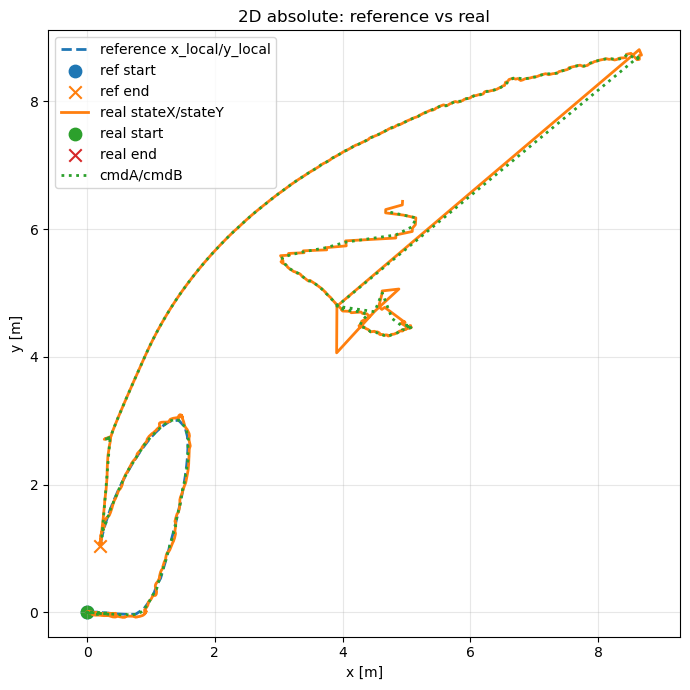

In [4]:
plt.figure(figsize=(7, 7))

plt.plot(ref["x_ref"], ref["y_ref"], "--", linewidth=2, label="reference x_local/y_local")
plt.scatter(ref["x_ref"].iloc[0], ref["y_ref"].iloc[0], s=80, marker="o", label="ref start")
plt.scatter(ref["x_ref"].iloc[-1], ref["y_ref"].iloc[-1], s=80, marker="x", label="ref end")

if {"stateX", "stateY"}.issubset(log.columns):
    plt.plot(log["stateX"], log["stateY"], linewidth=2, label="real stateX/stateY")
    plt.scatter(log["stateX"].iloc[0], log["stateY"].iloc[0], s=80, marker="o", label="real start")
    plt.scatter(log["stateX"].iloc[-1], log["stateY"].iloc[-1], s=80, marker="x", label="real end")

if {"cmdA", "cmdB"}.issubset(log.columns):
    cmd_valid = log[np.isfinite(log["cmdA"]) & np.isfinite(log["cmdB"])]
    plt.plot(cmd_valid["cmdA"], cmd_valid["cmdB"], ":", linewidth=2, label="cmdA/cmdB")

plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("2D absolute: reference vs real")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(outdir, "01_2d_absolute_reference_vs_real.png"), dpi=220)
plt.show()


## 4. 2D plot only during trajectory following

如果 `mission_state == 2` 是 trajectory following，这张图只画真正跟踪阶段。  
这样可以避免 idle / hover / landing 部分干扰判断。


following segment rows: 2453
time: 11.30 s to 60.34 s


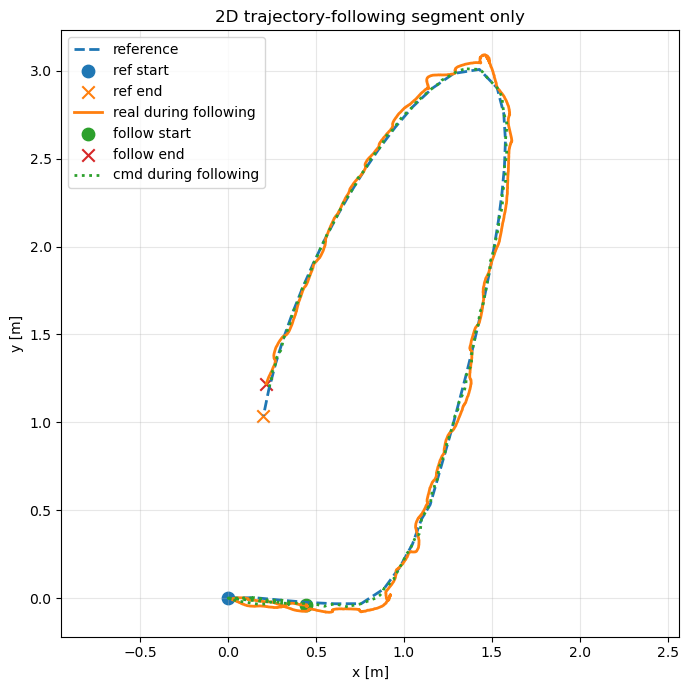

In [5]:
if "mission_state" in log.columns:
    follow = log[log["mission_state"] == 2].copy()
else:
    follow = log.copy()

if len(follow) < 2:
    print("No valid mission_state == 2 segment, using full log instead.")
    follow = log.copy()

print("following segment rows:", len(follow))
if len(follow) > 0:
    print(f"time: {follow['t'].iloc[0]:.2f} s to {follow['t'].iloc[-1]:.2f} s")

plt.figure(figsize=(7, 7))

plt.plot(ref["x_ref"], ref["y_ref"], "--", linewidth=2, label="reference")
plt.scatter(ref["x_ref"].iloc[0], ref["y_ref"].iloc[0], s=80, marker="o", label="ref start")
plt.scatter(ref["x_ref"].iloc[-1], ref["y_ref"].iloc[-1], s=80, marker="x", label="ref end")

if {"stateX", "stateY"}.issubset(follow.columns):
    plt.plot(follow["stateX"], follow["stateY"], linewidth=2, label="real during following")
    plt.scatter(follow["stateX"].iloc[0], follow["stateY"].iloc[0], s=80, marker="o", label="follow start")
    plt.scatter(follow["stateX"].iloc[-1], follow["stateY"].iloc[-1], s=80, marker="x", label="follow end")

if {"cmdA", "cmdB"}.issubset(follow.columns):
    cmd_follow = follow[np.isfinite(follow["cmdA"]) & np.isfinite(follow["cmdB"])]
    if len(cmd_follow) > 0:
        plt.plot(cmd_follow["cmdA"], cmd_follow["cmdB"], ":", linewidth=2, label="cmd during following")

plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("2D trajectory-following segment only")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(outdir, "02_2d_following_segment.png"), dpi=220)
plt.show()


## 5. Start-aligned plot

这张图把 reference 和 real 都平移到自己的起点。  
如果 start-aligned 图能对上，而 absolute 图对不上，说明主要是初始坐标 offset。  
如果 start-aligned 也对不上，说明轨迹形状/执行本身有问题。


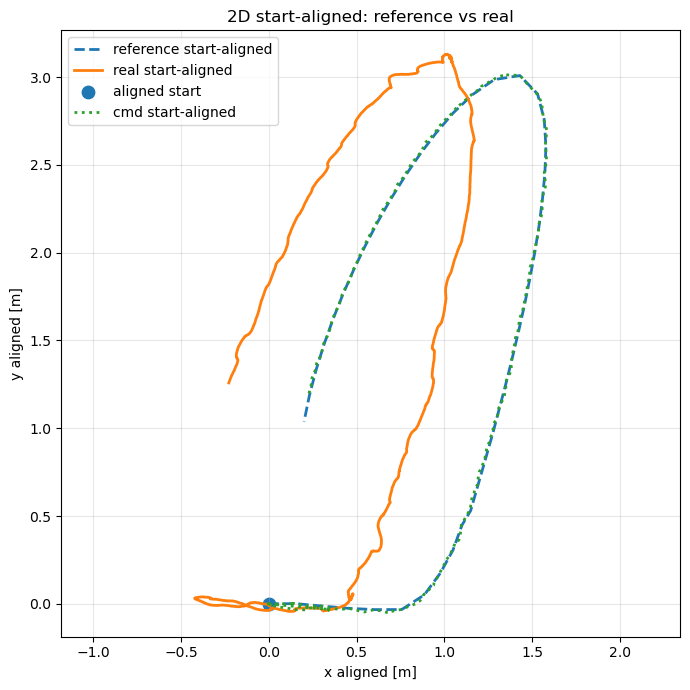

In [6]:
# 用 following 段做 start-aligned，因为它更接近真正 tracking 过程
real = follow.copy()

ref_xa = ref["x_ref"] - ref["x_ref"].iloc[0]
ref_ya = ref["y_ref"] - ref["y_ref"].iloc[0]

plt.figure(figsize=(7, 7))
plt.plot(ref_xa, ref_ya, "--", linewidth=2, label="reference start-aligned")

if {"stateX", "stateY"}.issubset(real.columns) and len(real) > 0:
    real_xa = real["stateX"] - real["stateX"].iloc[0]
    real_ya = real["stateY"] - real["stateY"].iloc[0]
    plt.plot(real_xa, real_ya, linewidth=2, label="real start-aligned")
    plt.scatter(0, 0, s=80, marker="o", label="aligned start")

if {"cmdA", "cmdB"}.issubset(real.columns) and len(real) > 0:
    cmd_valid = real[np.isfinite(real["cmdA"]) & np.isfinite(real["cmdB"])]
    if len(cmd_valid) > 0:
        cmd_xa = cmd_valid["cmdA"] - cmd_valid["cmdA"].iloc[0]
        cmd_ya = cmd_valid["cmdB"] - cmd_valid["cmdB"].iloc[0]
        plt.plot(cmd_xa, cmd_ya, ":", linewidth=2, label="cmd start-aligned")

plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.xlabel("x aligned [m]")
plt.ylabel("y aligned [m]")
plt.title("2D start-aligned: reference vs real")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(outdir, "03_2d_start_aligned.png"), dpi=220)
plt.show()


## 6. Show trajectory progress with command points

这张图重点看 firmware 实际 command 的点是否沿着 reference 走。  
如果 `cmdA/cmdB` 只走到 reference 的前几段，说明 FSM 没有完整执行全部 reference。


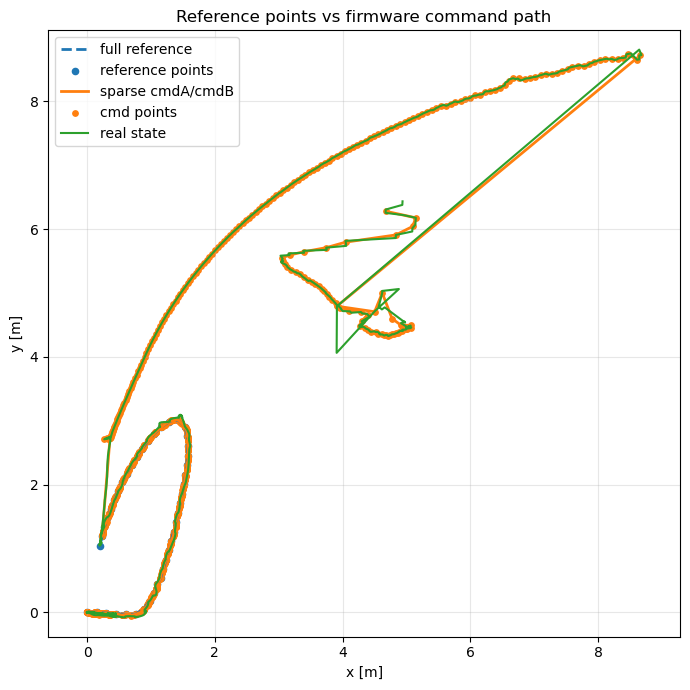

In [7]:
plt.figure(figsize=(7, 7))

plt.plot(ref["x_ref"], ref["y_ref"], "--", linewidth=2, label="full reference")
plt.scatter(ref["x_ref"], ref["y_ref"], s=20, label="reference points")

if {"cmdA", "cmdB"}.issubset(log.columns):
    cmd = log[np.isfinite(log["cmdA"]) & np.isfinite(log["cmdB"])].copy()
    # 去掉连续重复点，让图更清楚
    if len(cmd) > 0:
        cmd["dx"] = cmd["cmdA"].diff().abs()
        cmd["dy"] = cmd["cmdB"].diff().abs()
        cmd_sparse = cmd[(cmd["dx"].fillna(1) + cmd["dy"].fillna(1)) > 1e-4]
        plt.plot(cmd_sparse["cmdA"], cmd_sparse["cmdB"], linewidth=2, label="sparse cmdA/cmdB")
        plt.scatter(cmd_sparse["cmdA"], cmd_sparse["cmdB"], s=15, label="cmd points")

if {"stateX", "stateY"}.issubset(log.columns):
    plt.plot(log["stateX"], log["stateY"], linewidth=1.5, label="real state")

plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("Reference points vs firmware command path")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(outdir, "04_reference_vs_command_points.png"), dpi=220)
plt.show()


## 7. Minimal conclusion helper


In [8]:
print("========== Minimal diagnosis ==========")

if {"stateX", "stateY"}.issubset(log.columns):
    print(f"real start: ({log['stateX'].iloc[0]:+.3f}, {log['stateY'].iloc[0]:+.3f})")
    print(f"real end:   ({log['stateX'].iloc[-1]:+.3f}, {log['stateY'].iloc[-1]:+.3f})")

print(f"ref start:  ({ref['x_ref'].iloc[0]:+.3f}, {ref['y_ref'].iloc[0]:+.3f})")
print(f"ref end:    ({ref['x_ref'].iloc[-1]:+.3f}, {ref['y_ref'].iloc[-1]:+.3f})")

if {"cmdA", "cmdB"}.issubset(log.columns):
    cmd = log[np.isfinite(log["cmdA"]) & np.isfinite(log["cmdB"])]
    if len(cmd) > 0:
        print(f"cmd end:    ({cmd['cmdA'].iloc[-1]:+.3f}, {cmd['cmdB'].iloc[-1]:+.3f})")
        print(f"cmd range x: {cmd['cmdA'].min():+.3f} to {cmd['cmdA'].max():+.3f}")
        print(f"cmd range y: {cmd['cmdB'].min():+.3f} to {cmd['cmdB'].max():+.3f}")

if "mission_state" in log.columns:
    print("\nmission_state counts:")
    print(log["mission_state"].value_counts(dropna=False).sort_index())

print("\nLook at:")
print("1. 01_2d_absolute_reference_vs_real.png")
print("2. 02_2d_following_segment.png")
print("3. 03_2d_start_aligned.png")
print("4. 04_reference_vs_command_points.png")


========== Minimal diagnosis ==========
real start: (-0.002, -0.000)
real end:   (+4.597, +nan)
ref start:  (+0.000, +0.000)
ref end:    (+0.201, +1.038)
cmd end:    (+4.673, +6.280)
cmd range x: -0.009 to +8.661
cmd range y: -0.051 to +8.740

mission_state counts:
mission_state
0.0     315
1.0     250
2.0    2453
3.0     102
4.0     150
5.0     100
6.0      50
7.0     250
8.0      35
9.0     570
NaN       1
Name: count, dtype: int64

Look at:
1. 01_2d_absolute_reference_vs_real.png
2. 02_2d_following_segment.png
3. 03_2d_start_aligned.png
4. 04_reference_vs_command_points.png
